# Task 3: Student Distribution and Correlation Analysis

Run the cells from top to bottom. Each section is kept separate so you can execute it one by one.

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path

OUTPUT_DIR = Path("task_3")
OUTPUT_DIR.mkdir(exist_ok=True)

_original_savefig = plt.savefig

def savefig_to_output(filename, *args, **kwargs):
    target_name = Path(filename).name
    return _original_savefig(OUTPUT_DIR / target_name, *args, **kwargs)

plt.savefig = savefig_to_output

In [3]:
# Create synthetic student dataset

np.random.seed(42)

students = []

names = [
    "Aarav", "Vivaan", "Aditya", "Vihaan", "Arjun",
    "Sai", "Reyansh", "Krishna", "Ishaan", "Shaurya",
    "Aanya", "Diya", "Saanvi", "Ananya", "Pari",
    "Navya", "Anika", "Myra", "Sara", "Riya",
    "Rahul", "Rohan", "Karan", "Suresh", "Amit",
    "Nabin", "Sita", "Ram", "Hari", "Gita",
    "Prakash", "Roshan", "Bibek", "Asmita", "Nisha",
    "Sunil", "Manish", "Alina", "Pooja", "Kabir",
    "Ritika", "Yash", "Aryan", "Sneha", "Ramesh",
    "Kushal", "Deepa", "Anmol", "Rupesh", "Suman"
]

for name in names:
    study_hours = round(np.random.uniform(1, 10), 1)
    sleep_hours = round(np.random.uniform(4, 9), 1)
    attendance_pct = round(np.random.uniform(60, 100), 1)
    noise = np.random.randint(-10, 10)

    score = (
        study_hours * 7
        + attendance_pct * 0.3
        + noise
    )

    score = round(min(max(score, 0), 100), 1)
    passed = "Pass" if score >= 40 else "Fail"

    students.append([
        name,
        study_hours,
        sleep_hours,
        attendance_pct,
        score,
        passed
    ])

df = pd.DataFrame(
    students,
    columns=[
        "name",
        "study_hours",
        "sleep_hours",
        "attendance_pct",
        "score",
        "passed"
    ]
)

df.to_csv("students.csv", index=False)

print("students.csv created successfully")

students.csv created successfully


In [4]:
# Load dataset

df = pd.read_csv("students.csv")

df.head()

,name,study_hours,sleep_hours,attendance_pct,score,passed
0,Aarav,4.4,8.8,89.3,53.6,Pass
1,Vivaan,5.0,4.5,78.4,51.5,Pass
2,Aditya,2.3,7.3,62.3,35.8,Fail
3,Vihaan,9.4,4.0,99.7,85.7,Pass
4,Arjun,3.7,6.6,77.3,55.1,Pass


In [5]:
# Print shape

print(df.shape)

(50, 6)


In [6]:
# Check missing values

print(df.isnull().sum())

name              0
study_hours       0
sleep_hours       0
attendance_pct    0
score             0
passed            0
dtype: int64


In [7]:
# Missing value percentage

missing_percent = (
    df.isnull().sum() / len(df)
) * 100

print(missing_percent)

name              0.0
study_hours       0.0
sleep_hours       0.0
attendance_pct    0.0
score             0.0
passed            0.0
dtype: float64


In [8]:
# Descriptive statistics

print(df.describe())

       study_hours  sleep_hours  attendance_pct      score
count    50.000000    50.000000       50.000000  50.000000
mean      5.196000     6.772000       78.740000  59.568000
std       2.466424     1.471365       11.103263  18.659915
min       1.300000     4.000000       60.000000  23.900000
25%       3.125000     5.500000       70.950000  45.475000
50%       4.900000     7.200000       79.100000  57.300000
75%       7.400000     7.850000       87.175000  71.550000
max       9.400000     8.900000       99.700000  93.300000


In [9]:
# Value counts of passed column

# Reload the file if this cell is run before the loading cell.
if 'passed' not in df.columns:
    df = pd.read_csv("students.csv")

print(df['passed'].value_counts())

passed
Pass    43
Fail     7
Name: count, dtype: int64


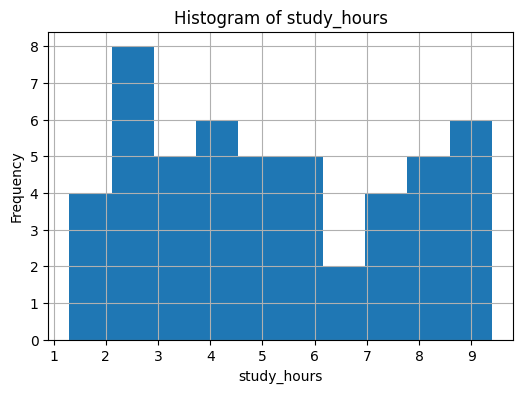

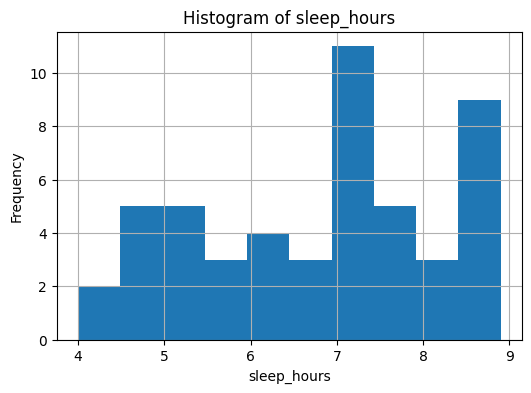

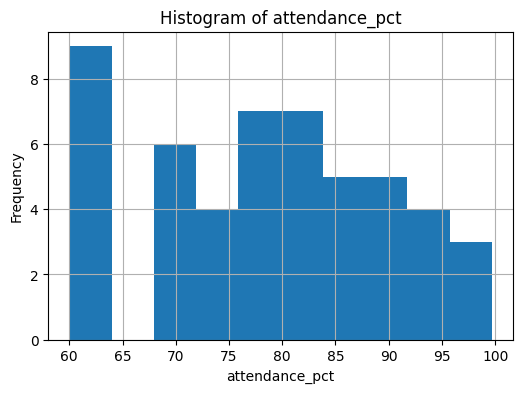

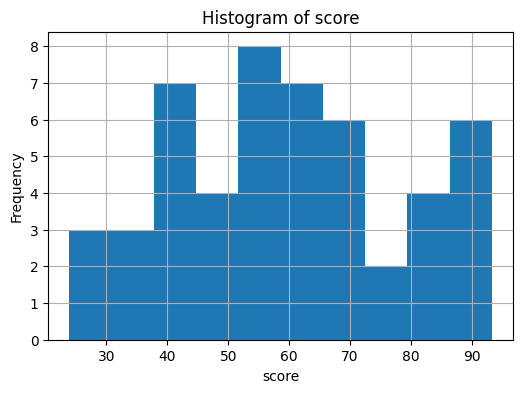

In [10]:
# Histogram for numeric columns

numeric_columns = [
    'study_hours',
    'sleep_hours',
    'attendance_pct',
    'score'
]

for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=10)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.savefig(f"{col}_histogram.png")
    plt.show()

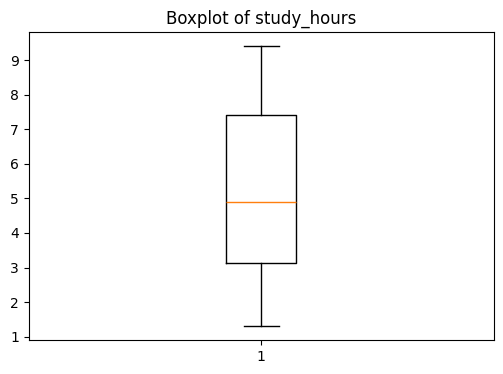

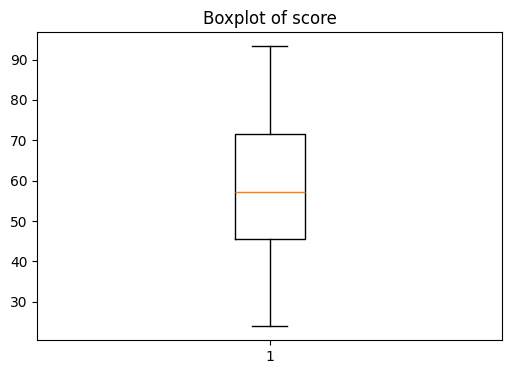

In [11]:
# Boxplot for study_hours and score

for col in ['study_hours', 'score']:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.savefig(f"{col}_boxplot.png")
    plt.show()

In [12]:
# Correlation matrix

correlation_matrix = df.corr(
    numeric_only=True
)

print(correlation_matrix)

                study_hours  sleep_hours  attendance_pct     score
study_hours        1.000000    -0.293641        0.063283  0.950581
sleep_hours       -0.293641     1.000000        0.195920 -0.253564
attendance_pct     0.063283     0.195920        1.000000  0.148854
score              0.950581    -0.253564        0.148854  1.000000


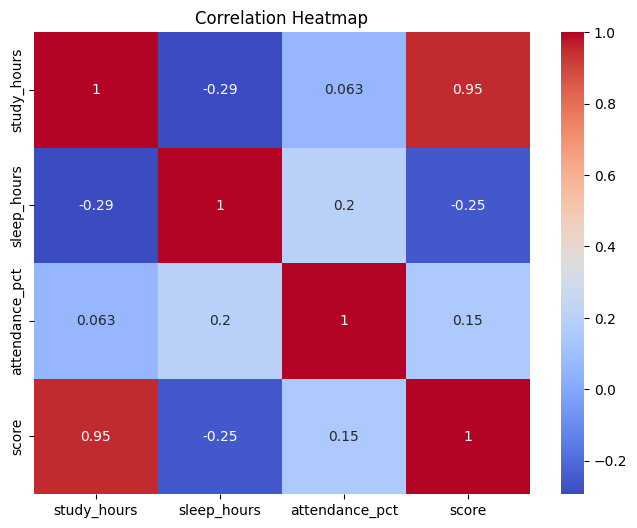

In [13]:
# Heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig("heatmap.png")

plt.show()

In [14]:
# Find strongest and weakest correlations

corr_pairs = correlation_matrix.unstack()

corr_pairs = corr_pairs[
    corr_pairs != 1
]

corr_pairs = corr_pairs.sort_values(
    ascending=False
)

print("Top 3 Strongest Correlations:\n")

print(corr_pairs.head(3))

print("\nTop 3 Weakest Correlations:\n")

print(corr_pairs.tail(3))

Top 3 Strongest Correlations:

study_hours  score             0.950581
score        study_hours       0.950581
sleep_hours  attendance_pct    0.195920
dtype: float64

Top 3 Weakest Correlations:

score        sleep_hours   -0.253564
sleep_hours  study_hours   -0.293641
study_hours  sleep_hours   -0.293641
dtype: float64


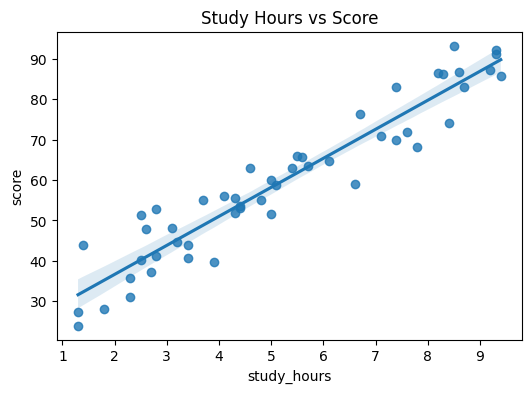

In [15]:
# Scatter plot 1

plt.figure(figsize=(6, 4))

sns.regplot(
    data=df,
    x='study_hours',
    y='score'
)

plt.title("Study Hours vs Score")

plt.savefig("study_vs_score.png")

plt.show()

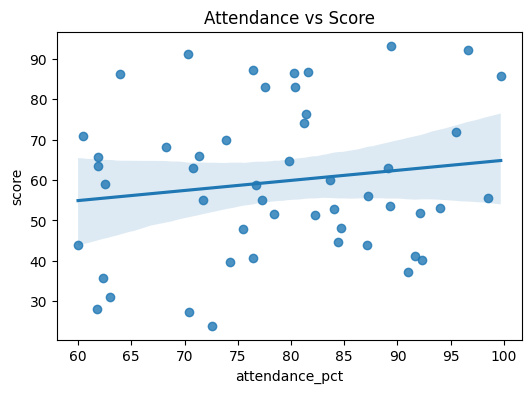

In [16]:
# Scatter plot 2

plt.figure(figsize=(6, 4))

sns.regplot(
    data=df,
    x='attendance_pct',
    y='score'
)

plt.title("Attendance vs Score")

plt.savefig("attendance_vs_score.png")

plt.show()

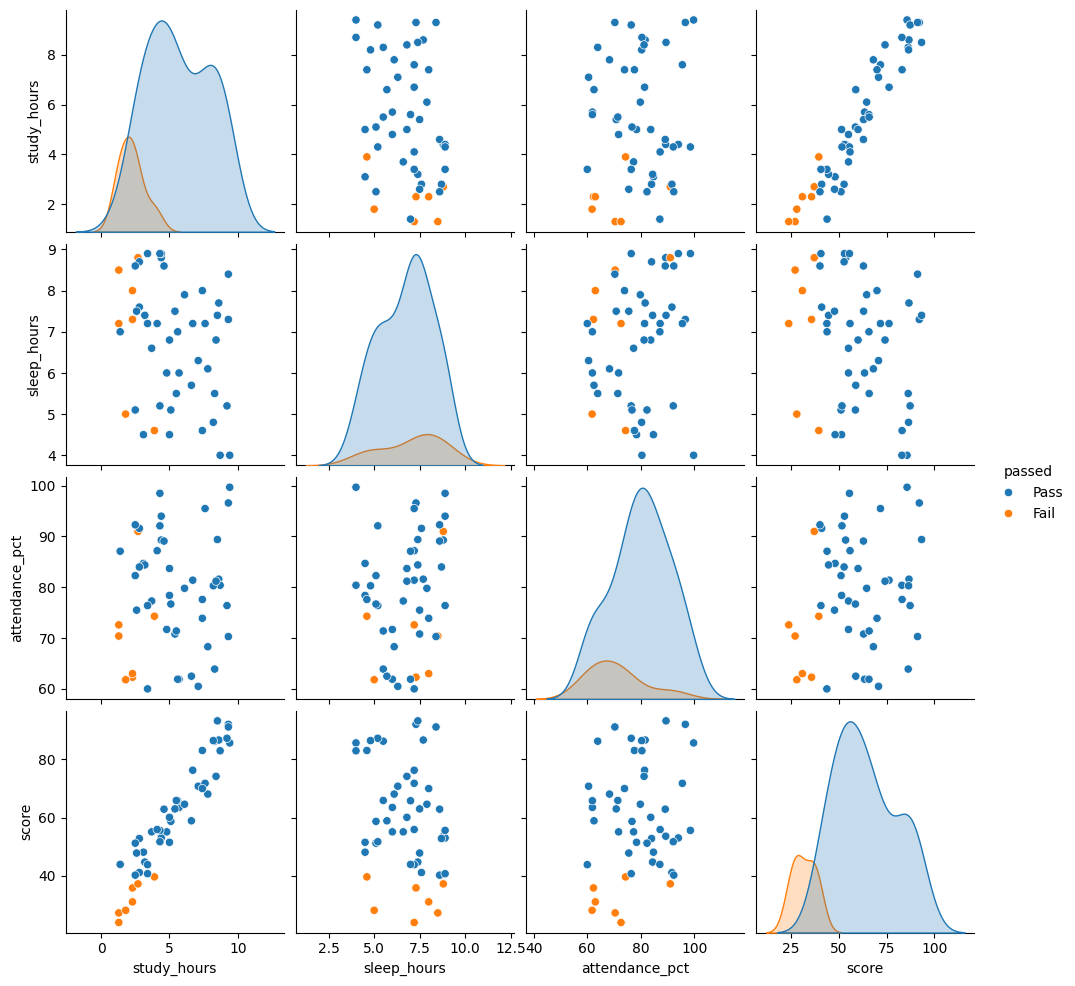

In [17]:
# Pairplot

sns.pairplot(
    df,
    hue='passed'
)

plt.savefig("pairplot.png")

plt.show()

In [18]:
# Final analysis

print("""

Analysis:

1. Students who study more generally score higher.

2. Attendance also positively affects score.

3. Sleep hours have weaker correlation with score.

4. Study hours do not always guarantee high score because noise/randomness was added.

5. Pairplot shows pass/fail students forming partial clusters.

""")



Analysis:

1. Students who study more generally score higher.

2. Attendance also positively affects score.

3. Sleep hours have weaker correlation with score.

4. Study hours do not always guarantee high score because noise/randomness was added.

5. Pairplot shows pass/fail students forming partial clusters.


